In [ ]:
# %pip install seaborn

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

Working with 'tips' smaple dataset - part of the seaborn (sns) package

This dataset contains information about tips at a restaurant (including meal time, party size, gender of customer, total bill amount, and tip amount)

In [2]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

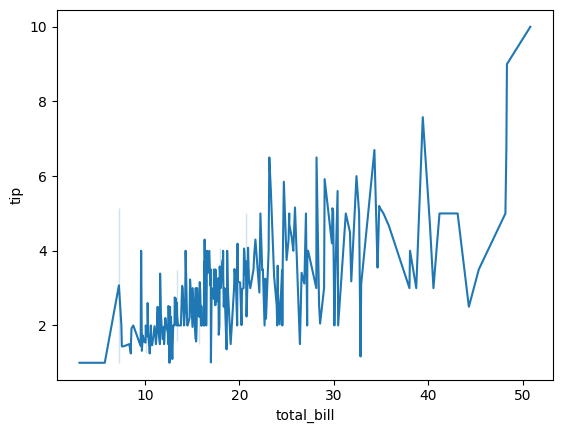

In [3]:
# make a simple line plot of tip amount vs total bill

sns.lineplot(data = tips,        # choose our dataset
             x = 'total_bill',   # define our x variable
             y='tip')            # define our y variable

<Axes: xlabel='total_bill', ylabel='tip'>

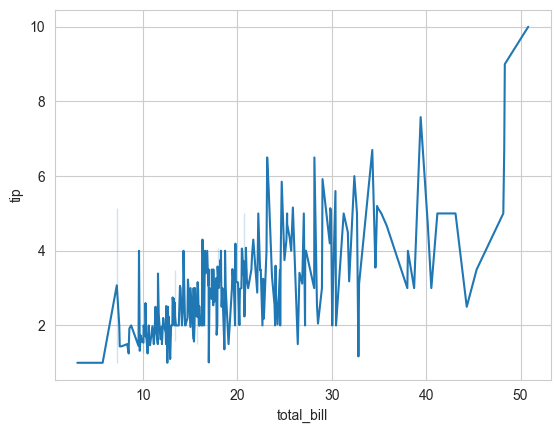

In [4]:
# we can use premaade styles to alter the appearance of the plot:

sns.set_style('whitegrid') # any future graphs will have this setting unless changed. Other styles include: 'darkgrid', 'dark', 'white', 'ticks'...
sns.lineplot(data = tips,        # choose our dataset
             x='total_bill',   # define our x variable
             y='tip')            # define our y variable


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

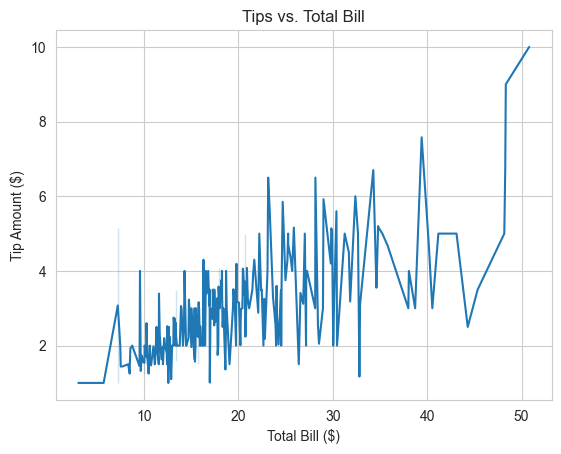

In [5]:
# add labels using set. function

tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip')

tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

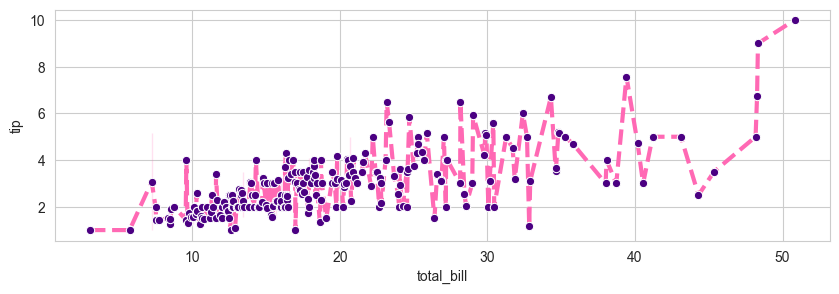

In [6]:
# we can lso change colour, marker style, and line style...
fig = plt.subplots(figsize=(10, 3)) # like in base matplotlib, we can use the subplots function to change figure size
sns.set_style('dark')
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip',
                        color = 'hotpink',
                        linestyle = '--',
                        linewidth = 3,
                        marker = 'o',
                        markerfacecolor = 'indigo')


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

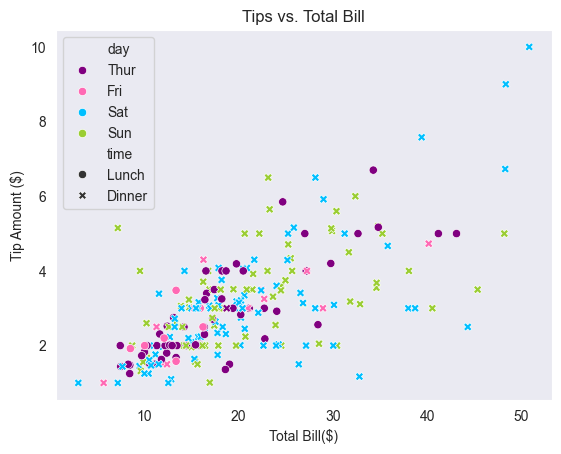

In [7]:
# Seaborn makes it very easy to represent multiple variables with different visual elements of our graph
tipgraph = sns.scatterplot(data=tips, x='total_bill', y='tip', style = 'time', hue = 'day', palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])
tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill($)', ylabel='Tip Amount ($)')

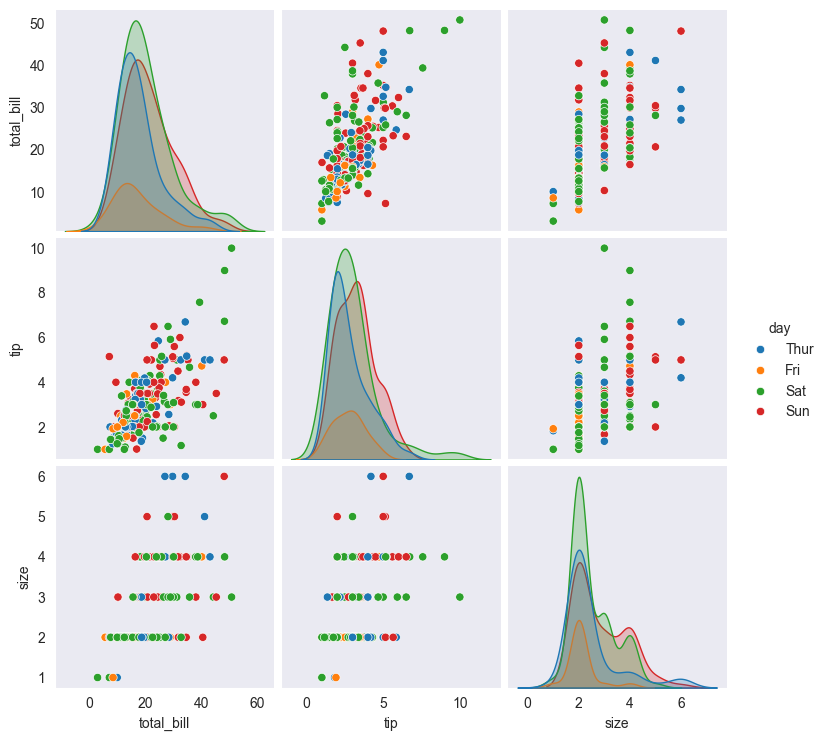

In [8]:
# Pairplot - another convenient way to compare variables
#sns.pairplot(data=tips) # only represents quantitative data not qualitative
sns.pairplot(data=tips, hue='day')

# this is good for exploratory analysis...

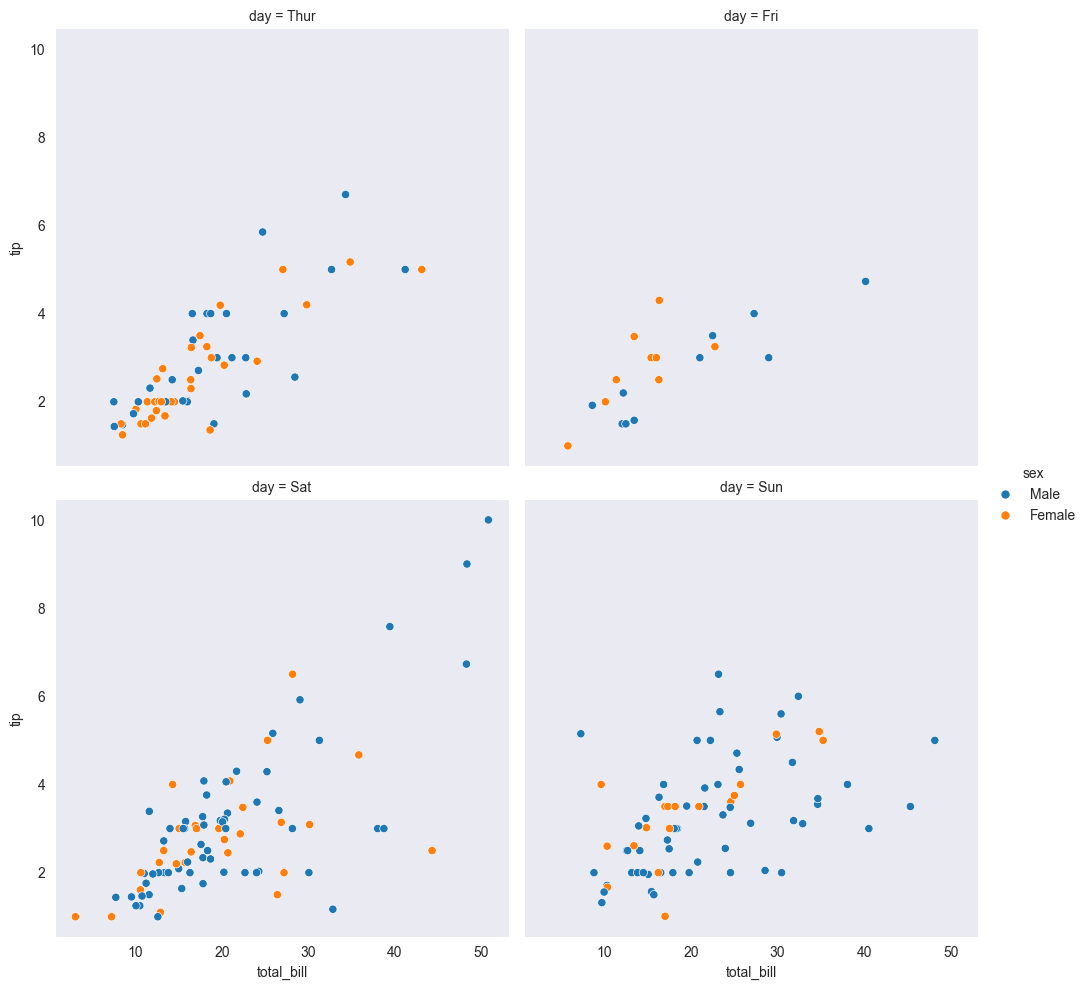

In [9]:
# ACTIVITY: comment this snippet of code and describe what each new element is doing.

# Relplot lets us explore specific levels within variables:
daysplot = sns.relplot(data=tips, # choose our dataset
                      x='total_bill', # set our x axis
                      y='tip', # set our y axis
                      hue = 'sex', # colour different data points into sex categories - blue male, female orange
                      col = 'day', #set different columns to days
                      kind = 'scatter', # use scatter plot for each panel
                      col_wrap = 2) # wrap each coloum into 2 columns per row

Here is an amazing resource to consult when making visualizations in my research: https://seaborn.pydata.org/examples/index.html

Activity: Types of Changes

What types of changes occur when we interact with this dynamic data visualization? Which spatial and retinal elements stay constant and which change? If you are redesigning this vis, would you choose to make different changes? WHy or why not?

Can we make direct comparisons across different snapshots? NO! we would have to make notes. No identity preserving because the order changes (axis does not stay constant).
There are shifts in the axis (adjusting slightly) but the comparison still remains the same. This is immediate changes.
But if the x and y variables scales stay the same mostly, it would be a transitional change.
The retinal elements stay constant (like colour), but spatial change. 
The order of the y axis allows for us to see trends in a more clear way - but this kind of reordering makes it hard to compare between snapshots -- tradeoff!
They dynamic features allows us to see all the stories/aspects.


In [ ]:
# Plotly
#%pip install plotly

In [ ]:
#%pip install seaborn plotly wordcloud matplotlib-venn scipy pillow requests

In [ ]:
#%pip install nbformat

In [10]:
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [13]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

graph.update_layout( title="Pirate Scores", xaxis_title="Pirates", yaxis_title="Score")

#graph.write_html("pirategraph.html")


In [ ]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure() # creat a figure object using the Plotly package
graph.add_trace(go.Scatter(x=x1, y=y1, mode = 'markers', # we want points for a scatter plot
                           marker=dict(
                               size =15,                          # point size
                               color='hotpink',                   # point colour
                               opacity=1,                         # point transparency/alpha
                               line=dict(width=5, color='purple') #point outline
                           )))

graph.update_layout(title="Interactive Pirate Plot",
                    xaxis_title="Pirates",
                    yaxis_title="Score",
                    width=500, height=500)

MAKING WORDCLOUDS -- qualitative

In [15]:
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

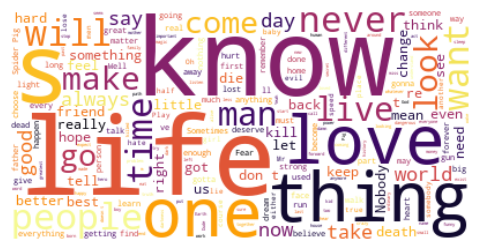

In [17]:
# make a simple word cloud using the 'quote' variable:

# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color='white',
                      colormap='inferno').generate(text)

#use matplotlib syntax to put our image in afigure

fig, ax=plt.subplots(figsize=(7,3))
ax.imshow(wordcloud,        # remember 'imshow' from when we added pictures to our matloblib axes
          interpolation = 'bilinear') # this line helps smooth our image
ax.axis("off")

Making venn diagrams - another qualitative graph:

/Users/serenemoussaoui/Documents/Work/DSI - 2026 Certification/visualization/visualization-env/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


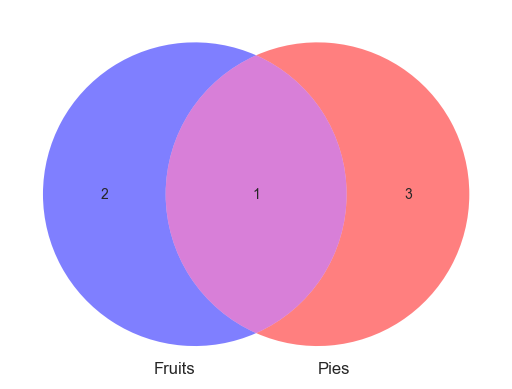

In [20]:
# use the matplotlib_venn extension to make venn diagrams
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

# then define our sets:
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# then assign sets to each circle and modify the appearance:
diagram = venn2_unweighted([A,B],
                           set_labels=('Fruits', 'Pies'),
                           set_colors=('blue', 'red'),
                           alpha = 0.5)

/Users/serenemoussaoui/Documents/Work/DSI - 2026 Certification/visualization/visualization-env/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


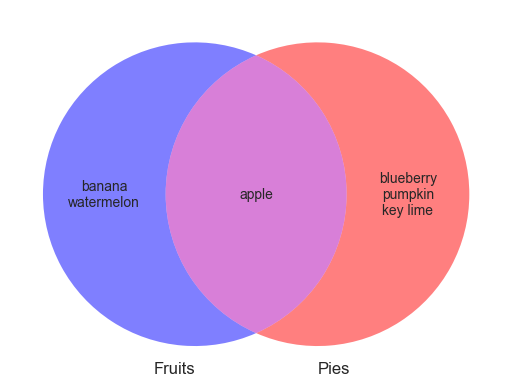

In [21]:
# as seen above, by default, our output will only show counts of how many items are in each set...
# we can modify the diagram to add labels:

# use the matplotlib_venn extension to make venn diagrams
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

# then define our sets:
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# then assign sets to each circle and modify the appearance:
diagram = venn2_unweighted([A,B],
                           set_labels=('Fruits', 'Pies'),
                           set_colors=('blue', 'red'),
                           alpha = 0.5)

diagram.get_label_by_id('10').set_text("\n".join(A - B))
diagram.get_label_by_id('11').set_text("\n".join(A & B))
diagram.get_label_by_id('01').set_text("\n".join(B - A))

The numbers in our brackets come from this documentation: https://github.com/konstantint/matplotlib-venn/blob/master/matplotlib_venn/_common.py#L12